# Tutorial: Calibration and spatial error analysis

This notebook focuses on one central question: **are forecasts not only accurate on average, but also calibrated and spatially useful?**

We run a rolling-origin evaluation pipeline and inspect results at multiple levels:

1. **Distributional reliability** (coverage and scoring rules),
2. **Hotspot utility** (whether top-risk areas are recovered),
3. **Spatial error structure** (where the model systematically over- or under-predicts).

The tutorial is designed for local execution with JIT enabled and GPU use when available.

In [1]:
import time
NB_START = time.perf_counter()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

from motac import (
    EdgeList,
    GridSpec,
    HawkesSimParams,
    HawkesModelSpec,
    MobilityHawkesModel,
    FitConfig,
    simulate_counts,
    rolling_backtest,
)

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
devices = jax.devices()
gpu_devices = [d for d in devices if d.platform == "gpu"]

print("Detected devices:", devices)
print("Default backend:", jax.default_backend())
if gpu_devices:
    print(f"GPU devices available: {len(gpu_devices)}")
else:
    print("No CUDA-enabled JAX backend detected for this run.")

Detected devices: [CudaDevice(id=0)]
Default backend: gpu
GPU devices available: 1


## 1) Build a controlled evaluation dataset with a custom road-style network

Instead of a smooth Gaussian stencil, we define a **hand-crafted sparse graph**:

- the top row acts as a high-connectivity "main road" corridor,
- three off-corridor hubs connect only to selected top-row segments,
- all other nodes keep mostly self-memory with weak spillovers.

This setup is useful for users who want to reason about explicit place-to-place links (roads / transit corridors / key venues) rather than isotropic diffusion.

In [3]:
grid = GridSpec(shape=(8, 8))
H, W = grid.shape
num_nodes = H * W
marks = ('battle', 'explosion', 'protest')


def node_id(r: int, c: int) -> int:
    return r * W + c


# Build a custom directed connectivity graph with a strong top-row corridor.
adj = np.zeros((num_nodes, num_nodes), dtype=np.float32)

# Give every node a self-edge so isolated areas keep local persistence.
for j in range(num_nodes):
    adj[j, j] = 0.45

# "Main road": top row with rightward-biased transport and short-range return flow.
road_nodes = [node_id(0, c) for c in range(W)]
for c, src in enumerate(road_nodes):
    if c < W - 1:
        adj[src, road_nodes[c + 1]] += 1.80
    if c > 0:
        adj[src, road_nodes[c - 1]] += 0.95
    if c < W - 2:
        adj[src, road_nodes[c + 2]] += 0.70

# Three off-corridor hubs that connect only to selected road segments.
feeder_specs = [
    ((3, 1), [1, 2, 3]),
    ((5, 4), [3, 4, 5]),
    ((6, 6), [5, 6, 7]),
]
feeder_nodes = []
for (r, c), road_cols in feeder_specs:
    hub = node_id(r, c)
    feeder_nodes.append(hub)

    for rc in road_cols:
        road = node_id(0, rc)
        adj[hub, road] += 1.55
        adj[road, hub] += 0.90

    # Keep each hub locally anchored to a small neighborhood.
    for dr, dc in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
        rr, cc = r + dr, c + dc
        if 0 <= rr < H and 0 <= cc < W:
            nbr = node_id(rr, cc)
            adj[hub, nbr] += 0.35
            adj[nbr, hub] += 0.20

# Row-normalize outgoing weights so each source distributes unit influence.
row_sum = adj.sum(axis=1, keepdims=True)
adj = adj / np.clip(row_sum, 1e-8, None)

src, dst = np.where(adj > 0)
weights = adj[src, dst].astype(np.float32)

coords = np.stack(np.meshgrid(np.arange(H), np.arange(W), indexing='ij'), axis=-1).reshape(-1, 2)
distance = np.linalg.norm(coords[src] - coords[dst], axis=1).astype(np.float32)

connectivity = EdgeList(
    src=jnp.asarray(src, dtype=jnp.int32),
    dst=jnp.asarray(dst, dtype=jnp.int32),
    weight=jnp.asarray(weights, dtype=jnp.float32),
    num_nodes=num_nodes,
    distance=jnp.asarray(distance, dtype=jnp.float32),
    meta={
        'kind': 'custom_road_corridor',
        'road_nodes': road_nodes,
        'feeder_nodes': feeder_nodes,
    },
)

params = HawkesSimParams(
    mu=0.02,
    alpha_from=jnp.array([0.24, 0.2, 0.16], dtype=jnp.float32),
    P_from_to=jnp.array([
        [0.75, 0.15, 0.10],
        [0.20, 0.65, 0.15],
        [0.20, 0.25, 0.55],
    ], dtype=jnp.float32),
    rho=jnp.array([
        [0.62, 0.86],
        [0.58, 0.83],
        [0.54, 0.79],
    ], dtype=jnp.float32),
    w_time=jnp.array([
        [0.72, 0.28],
        [0.66, 0.34],
        [0.58, 0.42],
    ], dtype=jnp.float32),
    obs='nb2',
    concentration=16.0,
)

counts = simulate_counts(
    T=56,
    grid=grid,
    num_nodes=num_nodes,
    marks=marks,
    connectivity=connectivity,
    params=params,
    seed=22,
)

print('Counts shape:', counts.y.shape)
print('Edge count:', len(src))
print('Average out-degree:', float((adj > 0).sum(axis=1).mean()))
counts.y.shape

Counts shape: (56, 64, 3)
Edge count: 126
Average out-degree: 1.96875


(56, 64, 3)

## 2) Visualize the custom connectivity

Before running calibration diagnostics, we inspect the graph directly so users can verify that the intended structure was encoded:

- a strong top-row corridor,
- selective feeder links from a few interior hubs,
- much weaker coupling elsewhere.

The left panel shows the spatial graph; the right panel shows a focused adjacency heatmap for road + feeder nodes.

Road node -> road corridor outgoing mass (per node): [1.    0.812 0.812 0.684 0.812 0.684 0.78  0.609]
Feeder hub -> road corridor outgoing mass: [0.715 0.715 0.715]


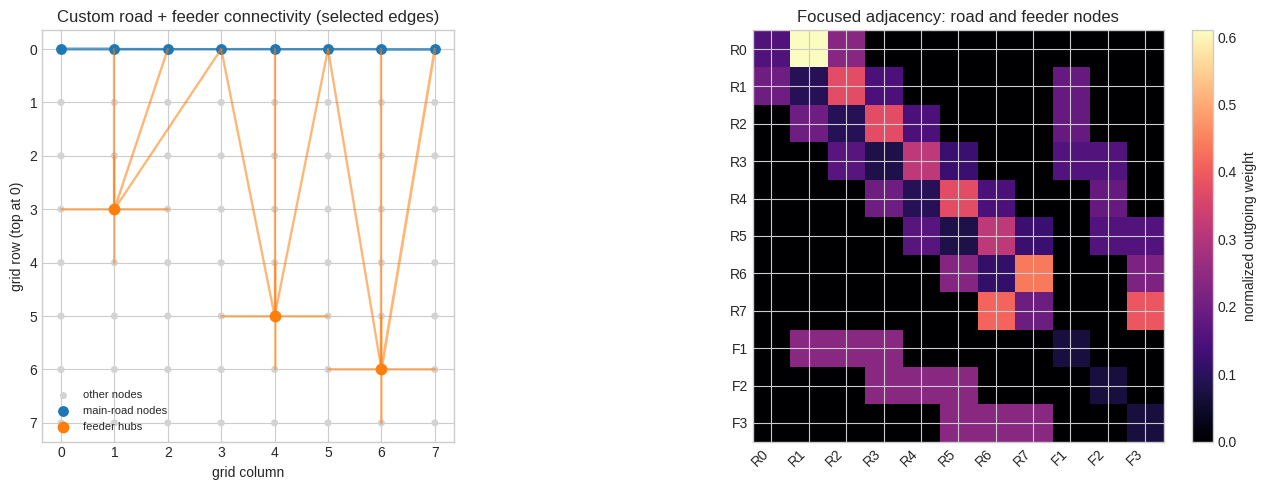

In [4]:
xy = np.stack([coords[:, 1], coords[:, 0]], axis=1)
road_set = set(road_nodes)
feeder_set = set(feeder_nodes)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: spatial graph view.
ax = axes[0]
ax.scatter(xy[:, 0], xy[:, 1], s=26, color='lightgray', edgecolor='none', label='other nodes')
ax.scatter(xy[road_nodes, 0], xy[road_nodes, 1], s=46, color='tab:blue', label='main-road nodes')
ax.scatter(xy[feeder_nodes, 0], xy[feeder_nodes, 1], s=56, color='tab:orange', label='feeder hubs')

for s, d, w in zip(src, dst, weights):
    if s == d:
        continue

    is_road_link = (s in road_set) and (d in road_set)
    is_feeder_link = (s in feeder_set) or (d in feeder_set)
    strong_link = w >= 0.22

    if not (is_road_link or is_feeder_link or strong_link):
        continue

    x0, y0 = xy[s]
    x1, y1 = xy[d]
    color = 'tab:blue' if is_road_link else ('tab:orange' if is_feeder_link else 'gray')
    ax.plot([x0, x1], [y0, y1], color=color, alpha=0.35, linewidth=1.1 + 2.5 * float(w))

ax.set_title('Custom road + feeder connectivity (selected edges)')
ax.set_xlabel('grid column')
ax.set_ylabel('grid row (top at 0)')
ax.legend(loc='lower left', fontsize=8)
ax.set_aspect('equal')
ax.invert_yaxis()

# Right: focused adjacency heatmap (road nodes + feeders only).
focus_nodes = road_nodes + feeder_nodes
focus_labels = [f'R{c}' for c in range(W)] + [f'F{i+1}' for i in range(len(feeder_nodes))]
focus_adj = adj[np.ix_(focus_nodes, focus_nodes)]

im = axes[1].imshow(focus_adj, cmap='magma', vmin=0.0, vmax=float(focus_adj.max()))
axes[1].set_title('Focused adjacency: road and feeder nodes')
axes[1].set_xticks(np.arange(len(focus_labels)))
axes[1].set_yticks(np.arange(len(focus_labels)))
axes[1].set_xticklabels(focus_labels, rotation=45, ha='right')
axes[1].set_yticklabels(focus_labels)
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, label='normalized outgoing weight')

plt.tight_layout()

road_out = adj[road_nodes][:, road_nodes].sum(axis=1)
feeder_to_road = adj[feeder_nodes][:, road_nodes].sum(axis=1)
print('Road node -> road corridor outgoing mass (per node):', np.round(road_out, 3))
print('Feeder hub -> road corridor outgoing mass:', np.round(feeder_to_road, 3))

## 3) Run rolling-origin backtests

We now fit and forecast repeatedly across time origins. This mimics deployment conditions where only historical data up to each origin are available.

Important arguments in `rolling_backtest(...)`:

- `horizon`: forecast length per split,
- `step`: stride between origins (larger values reduce overlap between test windows),
- `min_train`: minimum training history before first split,
- `fit_config`: inner optimization budget for each split,
- `forecast_samples`: posterior predictive sample count per split.

In [5]:
spec = HawkesModelSpec(marks=marks, temporal_bases=2, observation="nb2")
model = MobilityHawkesModel(spec)

bt = rolling_backtest(
    model,
    counts,
    horizon=4,
    step=4,
    min_train=28,
    fit_method="map_ensemble",
    fit_config=FitConfig(map_steps=16, map_ensemble_size=2, map_patience=6),
    forecast_samples=40,
    seed=33,
)

print("Number of rolling splits:", len(bt.splits))
metric_summary = bt.metrics[["log_score", "crps", "coverage_90", "hotspot_recall"]].describe().T
metric_summary

Number of rolling splits: 7


,count,mean,std,min,25%,50%,75%,max
log_score,7.0,-0.290163,0.025381,-0.321630,-0.310250,-0.293867,-0.267871,-0.259401
crps,7.0,0.078388,0.010946,0.065361,0.068368,0.081271,0.086406,0.092533
coverage_90,7.0,0.976004,0.005201,0.970052,0.972005,0.973958,0.980469,0.983073
hotspot_recall,7.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 4) Inspect split-level calibration traces

The table below exposes split-wise behavior directly (instead of only aggregate means), which is often where drift or instability first appears.

In [6]:
bt.metrics[["split", "coverage_90", "hotspot_recall", "log_score", "crps"]]

,split,coverage_90,hotspot_recall,log_score,crps
0,0,0.973958,1.0,-0.260326,0.065361
1,1,0.980469,1.0,-0.275415,0.070652
2,2,0.972656,1.0,-0.310645,0.085677
3,3,0.970052,1.0,-0.321630,0.092533
4,4,0.980469,1.0,-0.309854,0.087135
5,5,0.983073,1.0,-0.259401,0.066085
6,6,0.971354,1.0,-0.293867,0.081271


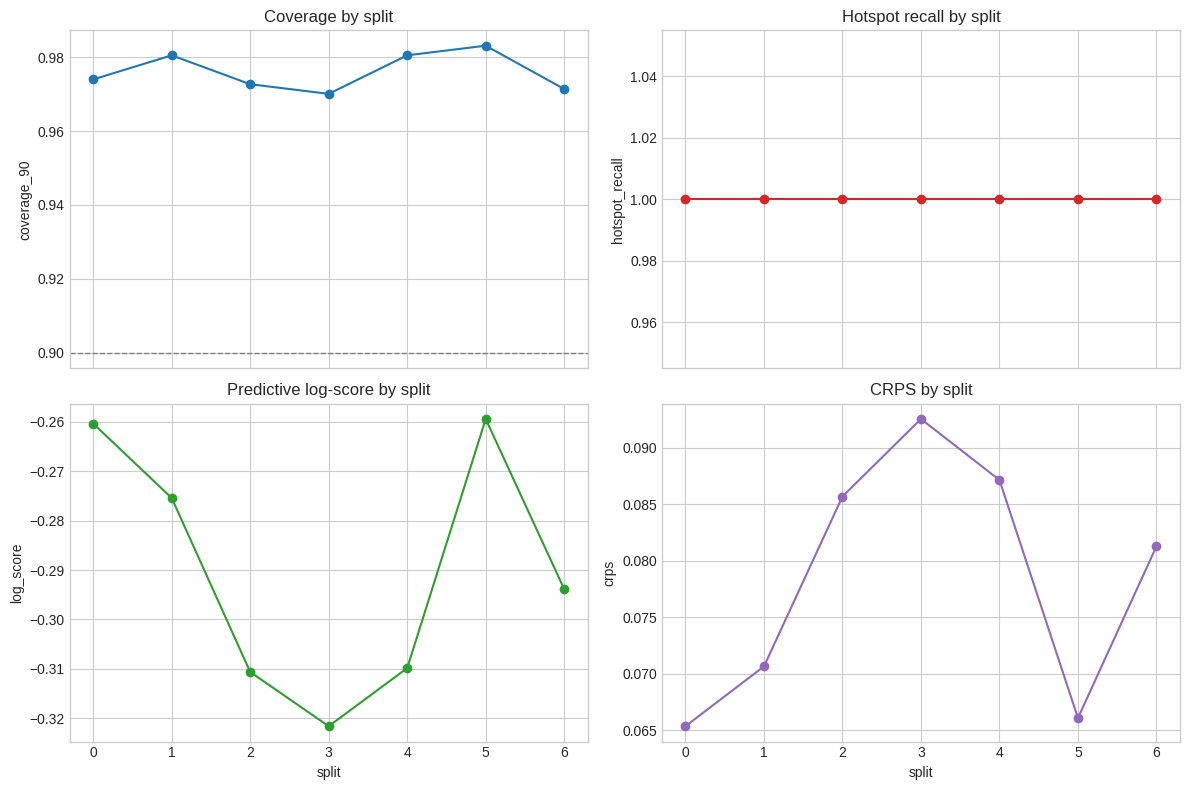

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

axes[0, 0].plot(bt.metrics["split"], bt.metrics["coverage_90"], marker="o")
axes[0, 0].axhline(0.9, linestyle="--", color="gray", linewidth=1)
axes[0, 0].set_title("Coverage by split")
axes[0, 0].set_ylabel("coverage_90")

axes[0, 1].plot(bt.metrics["split"], bt.metrics["hotspot_recall"], marker="o", color="tab:red")
axes[0, 1].set_title("Hotspot recall by split")
axes[0, 1].set_ylabel("hotspot_recall")

axes[1, 0].plot(bt.metrics["split"], bt.metrics["log_score"], marker="o", color="tab:green")
axes[1, 0].set_title("Predictive log-score by split")
axes[1, 0].set_xlabel("split")
axes[1, 0].set_ylabel("log_score")

axes[1, 1].plot(bt.metrics["split"], bt.metrics["crps"], marker="o", color="tab:purple")
axes[1, 1].set_title("CRPS by split")
axes[1, 1].set_xlabel("split")
axes[1, 1].set_ylabel("crps")

plt.tight_layout()

## 5) Compute split-wise spatial diagnostics

We compare observed and predicted spatial maps on each split, then inspect the final split as a map-level error decomposition.

Spatial diagnostics by split:
 split  spatial_mae  spatial_rmse  spatial_corr
     0     0.885156      1.096808      0.459436
     1     0.887109      1.122397      0.423661
     2     0.759375      0.982125      0.681079
     3     1.059375      1.652354      0.337553
     4     1.052734      1.385334      0.619574
     5     0.974609      1.283858      0.406453
     6     1.111719      1.481085      0.410081


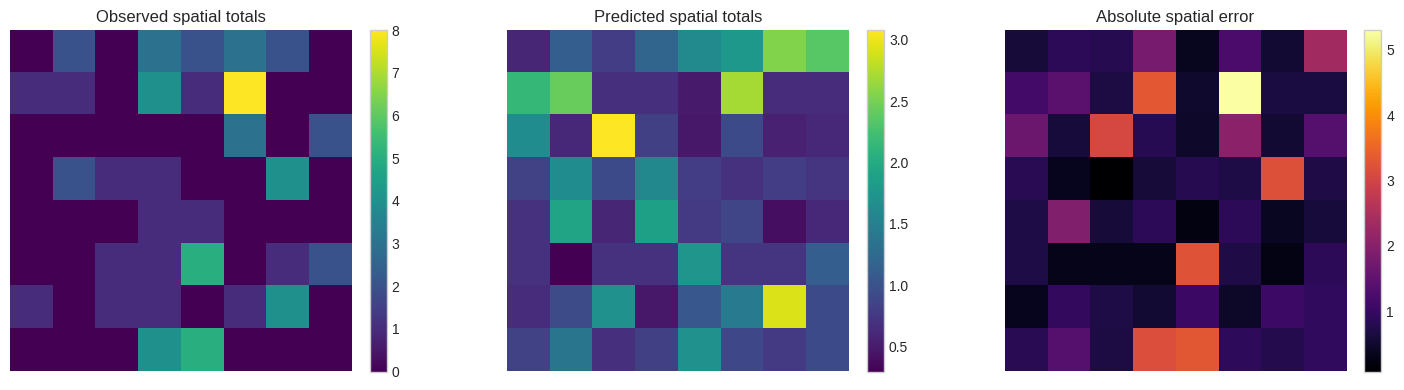

In [8]:
def safe_corr(a: np.ndarray, b: np.ndarray) -> float:
    a = a.reshape(-1)
    b = b.reshape(-1)
    if np.std(a) < 1e-8 or np.std(b) < 1e-8:
        return float("nan")
    return float(np.corrcoef(a, b)[0, 1])


rows = []
for i, (split, fc) in enumerate(zip(bt.splits, bt.forecasts)):
    y_true_spatial = np.asarray(split.test.y).sum(axis=(0, 2)).reshape(H, W)
    y_pred_spatial = np.asarray(fc.mean).sum(axis=(0, 2)).reshape(H, W)
    err = y_pred_spatial - y_true_spatial

    rows.append(
        {
            "split": i,
            "spatial_mae": float(np.mean(np.abs(err))),
            "spatial_rmse": float(np.sqrt(np.mean(err**2))),
            "spatial_corr": safe_corr(y_true_spatial, y_pred_spatial),
        }
    )

spatial_df = pd.DataFrame(rows)
print("Spatial diagnostics by split:")
print(spatial_df.to_string(index=False))

diag_split = len(bt.splits) - 1
y_true_map = np.asarray(bt.splits[diag_split].test.y).sum(axis=(0, 2)).reshape(H, W)
y_pred_map = np.asarray(bt.forecasts[diag_split].mean).sum(axis=(0, 2)).reshape(H, W)
y_err_map = np.abs(y_pred_map - y_true_map)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im0 = axes[0].imshow(y_true_map, cmap="viridis")
axes[0].set_title("Observed spatial totals")
axes[0].axis("off")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(y_pred_map, cmap="viridis")
axes[1].set_title("Predicted spatial totals")
axes[1].axis("off")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(y_err_map, cmap="inferno")
axes[2].set_title("Absolute spatial error")
axes[2].axis("off")
fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()

In [9]:
elapsed_sec = time.perf_counter() - NB_START
print(f'Notebook wall-clock runtime: {elapsed_sec:.2f} seconds ({elapsed_sec/60.0:.2f} minutes)')

Notebook wall-clock runtime: 201.78 seconds (3.36 minutes)


In [10]:
takeaways = [
    "Rolling-origin evaluation exposes temporal variation that aggregate summaries can hide.",
    "Coverage, CRPS/log-score, and hotspot metrics should be interpreted together.",
    "Spatial map diagnostics reveal local bias even when global metrics look acceptable.",
    "This workflow is a reusable reliability check before deployment on real datasets.",
]
print("Key takeaways:")
for line in takeaways:
    print(f"- {line}")

Key takeaways:
- Rolling-origin evaluation exposes temporal variation that aggregate summaries can hide.
- Coverage, CRPS/log-score, and hotspot metrics should be interpreted together.
- Spatial map diagnostics reveal local bias even when global metrics look acceptable.
- This workflow is a reusable reliability check before deployment on real datasets.
